**Assignment 6:** Path Planning for a Robot  
**Objective:** Use A* Search to find an optimal path for a robot navigating a 2D grid.  
**Problem Statement:** A robot must move from a start point to a goal in a grid while avoiding obstacles.  
**Tasks:**  
Implement A* with:
- The Manhattan distance heuristic applies to grids without any diagonal movement.
- The Euclidean distance heuristic is applicable to grids that allow diagonal movement.
- Use a plotting library to visualize the found path.
- Compare A* with BFS and Uniform Cost Search.

In [1]:
import heapq
import math
import time
from collections import deque

import matplotlib.pyplot as plt
import numpy as np

### Helpers: heuristics & neighbors

In [2]:
def manhattan(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])


def euclidean(a, b):
    return math.hypot(a[0] - b[0], a[1] - b[1])


def get_neighbors(pos, grid, allow_diagonal=False):
    """Return list of (neighbor_pos, step_cost)."""
    r, c = pos
    moves_4 = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    moves_8 = moves_4 + [(-1, -1), (-1, 1), (1, -1), (1, 1)]

    moves = moves_8 if allow_diagonal else moves_4
    out = []

    rows, cols = grid.shape
    for dr, dc in moves:
        nr, nc = r + dr, c + dc
        if 0 <= nr < rows and 0 <= nc < cols and grid[nr, nc] == 0:
            # Cost: 1 for straight, sqrt(2) for diagonal
            if allow_diagonal and dr != 0 and dc != 0:
                cost = math.sqrt(2)
            else:
                cost = 1.0
            out.append(((nr, nc), cost))
    return out


def reconstruct_path(parent, start, goal):
    if goal not in parent and goal != start:
        return None
    cur = goal
    path = [cur]
    while cur != start:
        cur = parent[cur]
        path.append(cur)
    path.reverse()
    return path


def path_cost(path, allow_diagonal=False):
    if not path or len(path) == 1:
        return 0.0
    total = 0.0
    for (r1, c1), (r2, c2) in zip(path[:-1], path[1:]):
        dr, dc = abs(r1 - r2), abs(c1 - c2)
        if allow_diagonal and dr == 1 and dc == 1:
            total += math.sqrt(2)
        else:
            total += 1.0
    return total

### Algorithms: BFS, UCS, A*

In [3]:
def bfs(grid, start, goal, allow_diagonal=False):
    """BFS assumes unit costs; if diagonal allowed, it's still unit edges here,
    so BFS path is fewest steps, not necessarily minimum Euclidean cost."""
    t0 = time.perf_counter()

    q = deque([start])
    parent = {start: None}
    visited = set([start])
    expanded = 0

    while q:
        cur = q.popleft()
        expanded += 1
        if cur == goal:
            break
        for (nxt, _cost) in get_neighbors(cur, grid, allow_diagonal=allow_diagonal):
            if nxt not in visited:
                visited.add(nxt)
                parent[nxt] = cur
                q.append(nxt)

    t1 = time.perf_counter()
    path = reconstruct_path(parent, start, goal)
    return {
        "name": "BFS",
        "path": path,
        "expanded": expanded,
        "visited": visited,
        "time_ms": (t1 - t0) * 1000,
    }


def ucs(grid, start, goal, allow_diagonal=False):
    t0 = time.perf_counter()

    pq = [(0.0, start)]
    parent = {start: None}
    g = {start: 0.0}
    visited = set()
    expanded = 0

    while pq:
        cost, cur = heapq.heappop(pq)
        if cur in visited:
            continue
        visited.add(cur)
        expanded += 1

        if cur == goal:
            break

        for (nxt, step) in get_neighbors(cur, grid, allow_diagonal=allow_diagonal):
            new_g = cost + step
            if nxt not in g or new_g < g[nxt]:
                g[nxt] = new_g
                parent[nxt] = cur
                heapq.heappush(pq, (new_g, nxt))

    t1 = time.perf_counter()
    path = reconstruct_path(parent, start, goal)
    return {
        "name": "UCS",
        "path": path,
        "expanded": expanded,
        "visited": visited,
        "time_ms": (t1 - t0) * 1000,
    }


def astar(grid, start, goal, heuristic, allow_diagonal=False):
    t0 = time.perf_counter()

    pq = []
    heapq.heappush(pq, (heuristic(start, goal), 0.0, start))  # (f, g, node)

    parent = {start: None}
    g = {start: 0.0}
    closed = set()
    expanded = 0

    while pq:
        f, cur_g, cur = heapq.heappop(pq)
        if cur in closed:
            continue
        closed.add(cur)
        expanded += 1

        if cur == goal:
            break

        for (nxt, step) in get_neighbors(cur, grid, allow_diagonal=allow_diagonal):
            tentative_g = cur_g + step
            if nxt in closed:
                continue
            if nxt not in g or tentative_g < g[nxt]:
                g[nxt] = tentative_g
                parent[nxt] = cur
                nxt_f = tentative_g + heuristic(nxt, goal)
                heapq.heappush(pq, (nxt_f, tentative_g, nxt))

    t1 = time.perf_counter()
    path = reconstruct_path(parent, start, goal)
    return {
        "name": "A*",
        "path": path,
        "expanded": expanded,
        "visited": closed,
        "time_ms": (t1 - t0) * 1000,
    }

### Visualization

In [4]:
def plot_result(grid, start, goal, visited, path, title):
    rows, cols = grid.shape
    img = np.ones((rows, cols, 3), dtype=float)  # white

    # obstacles -> black
    img[grid == 1] = [0, 0, 0]

    # visited -> light gray
    for (r, c) in visited:
        if (r, c) != start and (r, c) != goal and grid[r, c] == 0:
            img[r, c] = [0.85, 0.85, 0.85]

    # path -> blue-ish
    if path:
        for (r, c) in path:
            if (r, c) != start and (r, c) != goal:
                img[r, c] = [0.3, 0.5, 1.0]

    # start -> green, goal -> red
    sr, sc = start
    gr, gc = goal
    img[sr, sc] = [0.2, 0.8, 0.2]
    img[gr, gc] = [0.9, 0.2, 0.2]

    plt.figure(figsize=(7, 7))
    plt.imshow(img, interpolation="nearest")
    plt.title(title)
    plt.xticks(range(cols))
    plt.yticks(range(rows))
    plt.grid(True, which="both", color="lightgray", linewidth=0.5)
    plt.show()

### Demo grid + comparison

=== 4-direction (no diagonal): Manhattan for A* ===
BFS: steps=34, cost=34.000, expanded=345, time=1.42ms
UCS: steps=34, cost=34.000, expanded=346, time=1.84ms
A*: steps=34, cost=34.000, expanded=200, time=1.19ms


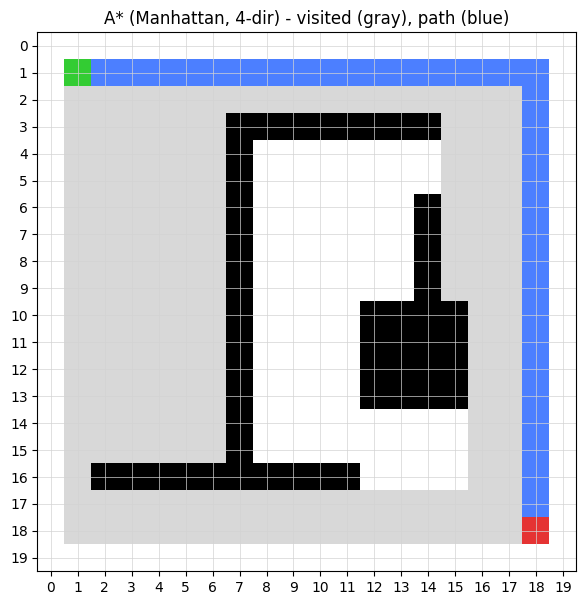


=== 8-direction (diagonal allowed): Euclidean for A* ===
BFS: steps=29, cost=31.071, expanded=345, time=3.01ms
UCS: steps=29, cost=31.071, expanded=345, time=4.93ms
A*: steps=29, cost=31.071, expanded=180, time=2.53ms


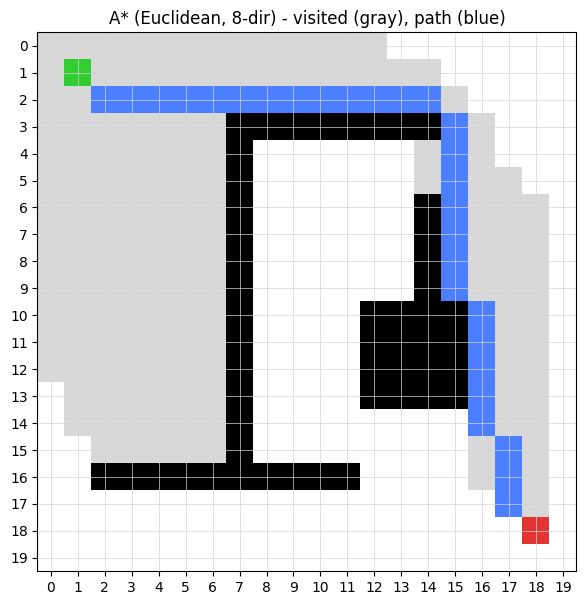

In [5]:
def run_demo():
    # 0 = free, 1 = obstacle
    grid = np.zeros((20, 20), dtype=int)

    # Add some obstacles (feel free to edit)
    grid[3:17, 7] = 1
    grid[3, 7:15] = 1
    grid[16, 2:12] = 1
    grid[10:14, 12:16] = 1
    grid[6:10, 14] = 1

    start = (1, 1)
    goal = (18, 18)

    print("=== 4-direction (no diagonal): Manhattan for A* ===")
    r_bfs_4 = bfs(grid, start, goal, allow_diagonal=False)
    r_ucs_4 = ucs(grid, start, goal, allow_diagonal=False)
    r_ast_4 = astar(grid, start, goal, heuristic=manhattan, allow_diagonal=False)

    for r in [r_bfs_4, r_ucs_4, r_ast_4]:
        p = r["path"]
        cost = path_cost(p, allow_diagonal=False) if p else float("inf")
        steps = len(p) - 1 if p else None
        print(f"{r['name']}: steps={steps}, cost={cost:.3f}, expanded={r['expanded']}, time={r['time_ms']:.2f}ms")

    plot_result(grid, start, goal, r_ast_4["visited"], r_ast_4["path"],
                "A* (Manhattan, 4-dir) - visited (gray), path (blue)")

    print("\n=== 8-direction (diagonal allowed): Euclidean for A* ===")
    # NOTE: BFS here finds min *steps*, not min *travel cost* when diagonals cost sqrt(2)
    r_bfs_8 = bfs(grid, start, goal, allow_diagonal=True)
    r_ucs_8 = ucs(grid, start, goal, allow_diagonal=True)
    r_ast_8 = astar(grid, start, goal, heuristic=euclidean, allow_diagonal=True)

    for r in [r_bfs_8, r_ucs_8, r_ast_8]:
        p = r["path"]
        cost = path_cost(p, allow_diagonal=True) if p else float("inf")
        steps = len(p) - 1 if p else None
        print(f"{r['name']}: steps={steps}, cost={cost:.3f}, expanded={r['expanded']}, time={r['time_ms']:.2f}ms")

    plot_result(grid, start, goal, r_ast_8["visited"], r_ast_8["path"],
                "A* (Euclidean, 8-dir) - visited (gray), path (blue)")


if __name__ == "__main__":
    run_demo()